In [1]:
import os
import glob
from enum import Enum

import torch
from torchvision.ops import box_iou

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches


In [2]:
class Channel(Enum):
    Player_1_Worker = 0
    Player_1_Ground = 1
    Player_1_Air = 2
    Player_1_Building = 3
    
    Player_2_Worker = 4
    Player_2_Ground = 5
    Player_2_Air = 6
    Player_2_Building = 7
    
    Resource = 8
    Vision = 9
    Terrain = 10

In [3]:
STORAGE_DIR = "/mnt/ex_ssd/starcraft-vision"

DATA_DIR = os.path.join(STORAGE_DIR, "data")
GROUND_TRUTH_DIR = os.path.join(DATA_DIR, "label", "dst")
PREDICTIONS_DIR = os.path.join(STORAGE_DIR, "predictions")

In [115]:
# REPLAYS = ['36.rep', '212.rep', '438.rep', '522.rep', '1660.rep', '6254.rep']
REPLAYS = ['1559.rep', '1628.rep', '2351.rep', '6219.rep', '11251.rep']

In [117]:
INFERENCE_MODEL_VANILLA = "vanilla/all_correct_win4_b16_20250812_062928/model_9"
INFERENCE_MODEL_KBRS = "kbrs/all_correct_win4_b16_kbrs_20250819_075939/model_9"

In [118]:
ground_truth_json_path = [
    f for name in REPLAYS
    for f in glob.glob(os.path.join(GROUND_TRUTH_DIR, name, '*.json'))
]

In [120]:
ground_truth_data = read_json_files(GROUND_TRUTH_DIR, label_method='all_correct', replays=REPLAYS)

In [121]:
def read_json_files(directory, label_method='all_correct', replays=None):
    data = []

    if replays:
        targets = [os.path.join(rep, f"{label_method}.json") for rep in replays]
    else:
        targets = os.listdir(directory)

    for filename in targets:
        if filename.endswith(".json"):
            filepath = os.path.join(directory, filename)
            if os.path.isfile(filepath):
                with open(filepath, "r", encoding="utf-8") as f:
                    data.append(json.load(f))

    return data

In [122]:
prediction_data = read_json_files(os.path.join(PREDICTIONS_DIR, INFERENCE_MODEL_VANILLA), label_method='all_correct', replays=REPLAYS)

In [123]:
def get_annotations(data, replay_suffix=".rep"):
    frames = []

    for item in (data or []):
        anns = item.get("annotations", [])
        if not anns:
            continue

        df = pd.DataFrame(anns)

        desc = (item.get("info") or {}).get("description", "") or ""
        replay_id = None
        if isinstance(desc, str) and desc.strip():
            replay_id = desc.strip().split()[-1]

        if replay_id is None:
            replay_id = "unknown"

        if replay_suffix and not str(replay_id).endswith(replay_suffix):
            replay_id = f"{replay_id}{replay_suffix}"

        df["replay"] = replay_id
        frames.append(df)

    base_cols = ["replay", "id", "image_id", "category_id", "bbox", "area", "segmentation", "iscrowd"]
    if not frames:
        return pd.DataFrame(columns=base_cols + ["score"])

    has_score = any("score" in f.columns for f in frames)

    wanted_cols = base_cols + (["score"] if has_score else [])
    for i, f in enumerate(frames):
        for col in wanted_cols:
            if col not in f.columns:
                frames[i][col] = pd.NA

    annotations = pd.concat(frames, ignore_index=True)

    return annotations[wanted_cols]

In [ ]:
annotation_ground_truth = get_annotations(ground_truth_data)
annotation_prediction = get_annotations(prediction_data)
# annotation_kbrs = 

In [125]:
def plot_occurrence_counts(ax, dataframe, xlabel, ylabel, title):
    counts = dataframe.groupby(['replay', 'image_id']).size()
    
    ax.hist(
        counts,
        bins=range(1, counts.max() + 2),
        edgecolor='black',
        align='left'
    )
    
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(0, max(counts.max(), counts.max()) + 1, 5))   

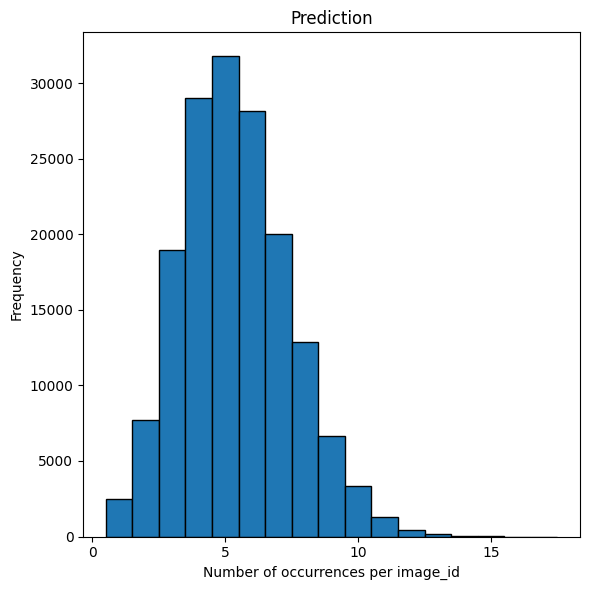

In [126]:
# fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=300, sharey=True)

# plot_occurrence_counts(axes[0], annotation_ground_truth, ylabel='Occurrences', title='Ground Truth Occurrences')
# plot_occurrence_counts(axes[1], annotation_prediction, ylabel='Occurrences', title='Prediction Occurrences')

# plt.tight_layout()
# plt.show()

fig, ax = plt.subplots(1, 1, figsize=(6, 6), dpi=100, sharey=True)

plot_occurrence_counts(ax, annotation_prediction, ylabel='Frequency', xlabel='Number of occurrences per image_id', title='Prediction')

plt.tight_layout()
plt.show()

In [127]:
def plot_prediction_score(ax, dataframe, xlabel, ylabel, title):
    
    ax.hist(
        dataframe['score'],
        bins=20,
        edgecolor='black',
        align='left'
    )
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)


In [128]:
def dataframe_topk_score(dataframe, K):
    topk_df = (
      dataframe.sort_values('score', ascending=False)
        .groupby(['replay', 'image_id'], group_keys=False)
        .head(K)
    )
    return topk_df.sort_values(['replay', 'image_id'])

In [129]:
top1_annotation_prediction = dataframe_topk_score(annotation_prediction, 1)
top3_annotation_prediction = dataframe_topk_score(annotation_prediction, 3)
top5_annotation_prediction = dataframe_topk_score(annotation_prediction, 5)

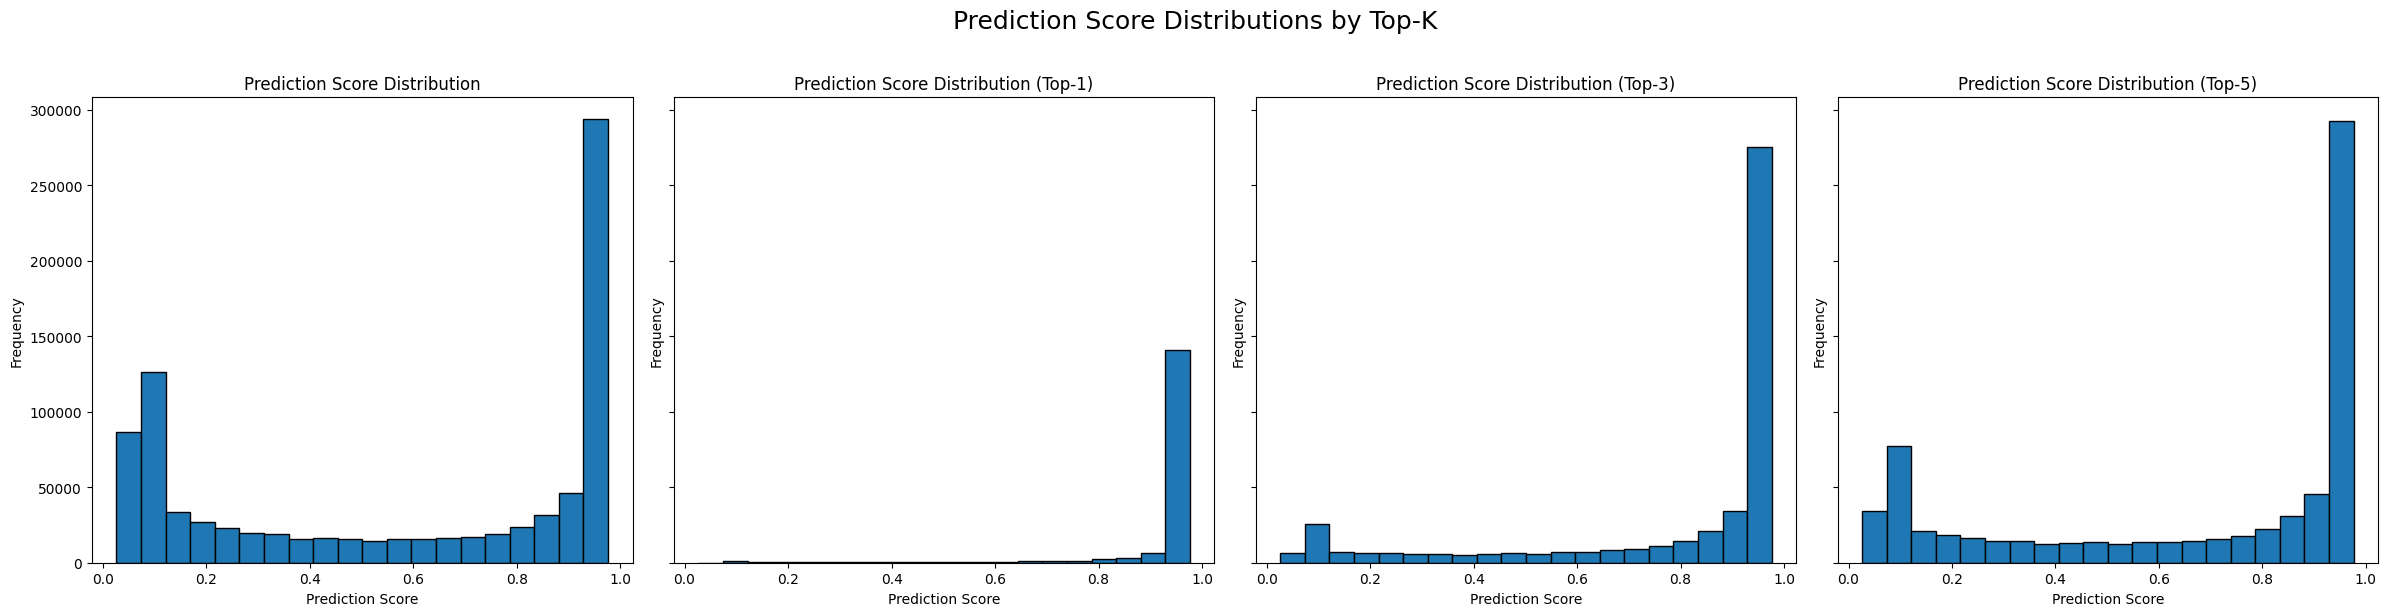

In [130]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6), dpi=100, sharey=True)

plot_prediction_score(axes[0], annotation_prediction, xlabel='Prediction Score', ylabel='Frequency', title='Prediction Score Distribution')
plot_prediction_score(axes[1], top1_annotation_prediction, xlabel='Prediction Score', ylabel='Frequency', title='Prediction Score Distribution (Top-1)')
plot_prediction_score(axes[2], top3_annotation_prediction, xlabel='Prediction Score', ylabel='Frequency', title='Prediction Score Distribution (Top-3)')
plot_prediction_score(axes[3], top5_annotation_prediction, xlabel='Prediction Score', ylabel='Frequency', title='Prediction Score Distribution (Top-5)')

fig.suptitle("Prediction Score Distributions by Top-K", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [131]:
# def compute_iou_box(box1, box2):
#     # box: [x, y, w, h] → convert to (x1, y1, x2, y2)
#     x1, y1, w1, h1 = box1
#     x2, y2, w2, h2 = box2

#     xi1 = max(x1, x2)
#     yi1 = max(y1, y2)
#     xi2 = min(x1 + w1, x2 + w2)
#     yi2 = min(y1 + h1, y2 + h2)

#     inter_area = max(xi2 - xi1, 0) * max(yi2 - yi1, 0)
#     union_area = w1 * h1 + w2 * h2 - inter_area

#     return inter_area / union_area if union_area > 0 else 0

In [132]:
# def evaluate_iou(gt_df, pred_df, iou_threshold=0.5):
#     results = []
#     keys_gt = set(zip(gt_df['replay'], gt_df['image_id']))
#     keys_pred = set(zip(pred_df['replay'], pred_df['image_id']))
#     shared_keys = sorted(keys_gt.intersection(keys_pred))  # 공통된 (replay, id)

#     for replay, frame_id in shared_keys:
#         gt_boxes = gt_df[(gt_df['replay'] == replay) & (gt_df['image_id'] == frame_id)]
#         pred_boxes = pred_df[(pred_df['replay'] == replay) & (pred_df['image_id'] == frame_id)]

#         matched_gt = set()
#         tp = 0
#         fp = 0
#         ious = []

#         for _, pred_row in pred_boxes.iterrows():
#             best_iou = 0
#             best_gt_idx = None
#             for _, gt_row in gt_boxes.iterrows():
#                 if gt_row['image_id'] in matched_gt:
#                     continue
#                 iou = compute_iou_box(pred_row['bbox'], gt_row['bbox'])
#                 if iou > best_iou:
#                     best_iou = iou
#                     best_gt_idx = gt_row['image_id']
#             if best_iou >= iou_threshold:
#                 tp += 1
#                 matched_gt.add(best_gt_idx)
#                 ious.append(best_iou)
#             else:
#                 fp += 1

#         fn = len(gt_boxes) - len(matched_gt)
#         precision = tp / (tp + fp) if (tp + fp) > 0 else 0
#         recall = tp / (tp + fn) if (tp + fn) > 0 else 0

#         results.append({
#             'replay': replay,
#             'image_id': frame_id,
#             'precision': precision,
#             'recall': recall,
#             'mean_iou': np.mean(ious) if ious else 0,
#             'tp': tp,
#             'fp': fp,
#             'fn': fn
#         })

#     return pd.DataFrame(results)

In [133]:
# def evaluate_single_iou_pre_split(args):
#     (replay, image_id), gt_bboxes, pred_bboxes, iou_threshold = args

#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     gt_boxes = torch.tensor(gt_bboxes, dtype=torch.float, device=device)
#     pred_boxes = torch.tensor(pred_bboxes, dtype=torch.float, device=device)

#     matched_gt = set()
#     tp, fp, fn = 0, 0, 0
#     ious = []

#     if len(gt_boxes) == 0:
#         tp, fp = 0, len(pred_boxes)
#     elif len(pred_boxes) == 0:
#         fn = len(gt_boxes)
#     else:
#         iou_matrix = box_iou(pred_boxes, gt_boxes)
#         for pred_idx in range(iou_matrix.size(0)):
#             ious_row = iou_matrix[pred_idx]
#             best_iou, best_gt_idx = torch.max(ious_row, dim=0)
#             if best_iou >= iou_threshold and best_gt_idx.item() not in matched_gt:
#                 tp += 1
#                 ious.append(best_iou.item())
#                 matched_gt.add(best_gt_idx.item())
#             else:
#                 fp += 1
#         fn = len(gt_boxes) - len(matched_gt)

#     precision = tp / (tp + fp) if tp + fp > 0 else 0
#     recall = tp / (tp + fn) if tp + fn > 0 else 0

#     return {
#         'replay': replay,
#         'image_id': image_id,
#         'precision': precision,
#         'recall': recall,
#         'mean_iou': np.mean(ious) if ious else 0,
#         'tp': tp,
#         'fp': fp,
#         'fn': fn
#     }


In [134]:
# from collections import defaultdict

# def make_frame_dict(df):
#     frame_dict = defaultdict(list)
#     for _, row in df.iterrows():
#         key = (row['replay'], row['image_id'])
#         frame_dict[key].append(row['bbox'])
#     return {k: np.array(v) for k, v in frame_dict.items()}

In [135]:
# from multiprocessing import Pool

# def evaluate_iou_pre_split_parallel(gt_df, pred_df, iou_threshold=0.5, num_workers=None):
#     if num_workers is None:
#         from multiprocessing import cpu_count
#         num_workers = cpu_count()

#     gt_dict = make_frame_dict(gt_df)
#     pred_dict = make_frame_dict(pred_df)
#     shared_keys = sorted(set(gt_dict) & set(pred_dict))

#     args_list = [
#         ((replay, image_id), gt_dict[(replay, image_id)], pred_dict[(replay, image_id)], iou_threshold)
#         for (replay, image_id) in shared_keys
#     ]

#     with Pool(processes=num_workers) as pool:
#         results = pool.map(evaluate_single_iou_pre_split, args_list)

#     return pd.DataFrame(results)


In [136]:
# results = evaluate_iou_pre_split_parallel(annotation_ground_truth, annotation_prediction)

In [137]:
# results_top1 = evaluate_iou_pre_split_parallel(annotation_ground_truth, top1_annotation_prediction)
# results_top3 = evaluate_iou_pre_split_parallel(annotation_ground_truth, top3_annotation_prediction)
# results_top5 = evaluate_iou_pre_split_parallel(annotation_ground_truth, top5_annotation_prediction)

In [138]:
# def get_statistics(dataframe, label):
#     stats = {
#         "mean_precision": dataframe["precision"].mean(),
#         "mean_recall": dataframe["recall"].mean(),
#         "mean_iou": dataframe["mean_iou"].mean(),
#         "total_tp": dataframe["tp"].sum(),
#         "total_fp": dataframe["fp"].sum(),
#         "total_fn": dataframe["fn"].sum()
#     }

#     # 전체 F1-score (마이크로 방식)
#     if stats["total_tp"] > 0:
#         stats["f1_score"] = 2 * stats["total_tp"] / (2 * stats["total_tp"] + stats["total_fp"] + stats["total_fn"])
#     else:
#         stats["f1_score"] = 0.0

#     return pd.Series(stats, name=label)


In [139]:
# train_set = ['36.rep', '212.rep', '438.rep', '522.rep', '1660.rep']
# test_set = ['6254.rep']

In [140]:
# stat_train = get_statistics(results.loc[results['replay'].isin(train_set)], 'total')
# stat_train_top1 = get_statistics(results_top1.loc[results_top1['replay'].isin(train_set)], 'top1')
# stat_train_top3 = get_statistics(results_top3.loc[results_top3['replay'].isin(train_set)], 'top3')
# stat_train_top5 = get_statistics(results_top5.loc[results_top5['replay'].isin(train_set)], 'top5')

In [141]:
# pd.set_option("display.float_format", "{:.4f}".format)
# pd.concat([stat_train, stat_train_top1, stat_train_top3, stat_train_top5], axis=1)

In [142]:
# stat_test = get_statistics(results.loc[results['replay'].isin(test_set)], 'total')
# stat_test_top1 = get_statistics(results_top1.loc[results_top1['replay'].isin(test_set)], 'top1')
# stat_test_top3 = get_statistics(results_top3.loc[results_top3['replay'].isin(test_set)], 'top3')
# stat_test_top5 = get_statistics(results_top5.loc[results_top5['replay'].isin(test_set)], 'top5')

In [143]:
# pd.concat([stat_test, stat_test_top1, stat_test_top3, stat_test_top5], axis=1)

In [144]:
# results_vanilla['model'] = 'vanilla'
# results_kbrs['model'] = 'kbrs'

# combined_results = pd.concat([results_vanilla, results_kbrs], ignore_index=True)
# summary = combined_results.groupby('model')[['precision', 'recall', 'mean_iou']].mean()

# summary

In [145]:
# def compute_frame_coverage(bboxes, frame_size=(128, 128)):
#     mask = np.zeros(frame_size, dtype=bool)
#     for bbox in bboxes:
#         x, y, w, h = map(int, bbox)
#         x1, y1 = max(x, 0), max(y, 0)
#         x2 = min(x + w, frame_size[1])
#         y2 = min(y + h, frame_size[0])
#         mask[y1:y2, x1:x2] = True
#     return np.sum(mask) / (frame_size[0] * frame_size[1])

In [146]:
# def compare_coverage_single_frame(args):
#     replay, frame_id, gt_dict, pred_dict, frame_size = args
#     gt_bboxes = gt_dict.get((replay, frame_id), [])
#     gt_cov = compute_frame_coverage(gt_bboxes, frame_size)

#     entry = {
#         'replay': replay,
#         'image_id': frame_id,
#         'gt_coverage': gt_cov,
#     }

#     for model_name, model_dict in pred_dict.items():
#         pred_bboxes = model_dict.get((replay, frame_id), [])
#         pred_cov = compute_frame_coverage(pred_bboxes, frame_size)
#         entry[f'{model_name}_coverage'] = pred_cov
#         entry[f'{model_name}_diff'] = abs(gt_cov - pred_cov)

#     return entry

In [147]:
# def compare_coverage_multiple_parallel(gt_df, pred_dict, frame_size=(128, 128), num_workers=None):
#     if num_workers is None:
#         num_workers = os.cpu_count()

#     # GT dict
#     gt_dict = {
#         (row['replay'], row['image_id']): []
#         for _, row in gt_df.iterrows()
#     }
#     for _, row in gt_df.iterrows():
#         gt_dict[(row['replay'], row['image_id'])].append(row['bbox'])

#     # 각 모델 예측 dict
#     pred_dict_by_model = {}
#     all_keys = set(gt_dict.keys())

#     for model_name, df in pred_dict.items():
#         model_dict = {}
#         for _, row in df.iterrows():
#             key = (row['replay'], row['image_id'])
#             model_dict.setdefault(key, []).append(row['bbox'])
#             all_keys.add(key)
#         pred_dict_by_model[model_name] = model_dict

#     # 작업 리스트
#     task_args = [
#         (replay, image_id, gt_dict, pred_dict_by_model, frame_size)
#         for (replay, image_id) in sorted(all_keys)
#     ]

#     with Pool(processes=num_workers) as pool:
#         results = pool.map(compare_coverage_single_frame, task_args)

#     return pd.DataFrame(results)


In [148]:
# coverage_df = compare_coverage_multiple_parallel(
#     gt_df=annotation_ground_truth,
#     pred_dict={
#         'vanilla': annotation_prediction,
#     }
# )

In [149]:
# coverage_df[['gt_coverage', 'vanilla_coverage', 'vanilla_diff', 'kbrs_coverage', 'kbrs_diff']].describe()

In [150]:
def draw_overview(data, rep_name, frame, ground_truths=None, segmentations_list=None, dataframe_list=None):
    plt.figure(figsize=(6, 6), dpi=300)

    # Terrain & resource
    plt.imshow(data[Channel.Terrain.value] > 0, cmap='Greys', alpha=0.5)
    resource_alpha = np.where(data[Channel.Resource.value] == 1, 1.0, 0.0)
    plt.imshow(data[Channel.Resource.value] == 1, cmap='GnBu', alpha=resource_alpha)

    # Player colors
    p1_cmap = 'Greens'
    p2_cmap = 'Reds'

    # Player 1 & 2 - worker
    player_1_worker_alpha = np.where(data[Channel.Player_1_Worker.value] != 0, 1.0, 0.0)
    player_2_worker_alpha = np.where(data[Channel.Player_2_Worker.value] != 0, 1.0, 0.0)
    plt.imshow(data[Channel.Player_1_Worker.value] != 0, cmap=p1_cmap, alpha=player_1_worker_alpha)
    plt.imshow(data[Channel.Player_2_Worker.value] != 0, cmap=p2_cmap, alpha=player_2_worker_alpha)

    # Player 1 & 2 - ground
    player_1_ground_alpha = np.where(data[Channel.Player_1_Ground.value] != 0, 1.0, 0.0)
    player_2_ground_alpha = np.where(data[Channel.Player_2_Ground.value] != 0, 1.0, 0.0)
    plt.imshow(data[Channel.Player_1_Ground.value] != 0, cmap=p1_cmap, alpha=player_1_ground_alpha)
    plt.imshow(data[Channel.Player_2_Ground.value] != 0, cmap=p2_cmap, alpha=player_2_ground_alpha)

    # Player 1 & 2 - air
    player_1_air_alpha = np.where(data[Channel.Player_1_Air.value] != 0, 1.0, 0.0)
    player_2_air_alpha = np.where(data[Channel.Player_2_Air.value] != 0, 1.0, 0.0)
    plt.imshow(data[Channel.Player_1_Air.value] != 0, cmap=p1_cmap, alpha=player_1_air_alpha)
    plt.imshow(data[Channel.Player_2_Air.value] != 0, cmap=p2_cmap, alpha=player_2_air_alpha)

    # Player 1 & 2 - building
    player_1_building_alpha = np.where(data[Channel.Player_1_Building.value] != 0, 1.0, 0.0)
    player_2_building_alpha = np.where(data[Channel.Player_2_Building.value] != 0, 1.0, 0.0)
    plt.imshow(data[Channel.Player_1_Building.value] != 0, cmap=p1_cmap, alpha=player_1_building_alpha)
    plt.imshow(data[Channel.Player_2_Building.value] != 0, cmap=p2_cmap, alpha=player_2_building_alpha)

    # Vision mask
    vision_alpha = np.where(data[Channel.Vision.value] == 1, 0.0, 0.9)
    plt.imshow(np.zeros_like(data[Channel.Vision.value]), cmap='Greys_r', alpha=vision_alpha)

    ax = plt.gca()

    if dataframe_list is not None:
        color = ['red', 'blue']  # 두 개 세그먼트용 색상
        for dataframe_idx, dataframe in enumerate(dataframe_list):
            for row in dataframe.itertuples():
                coords = np.array(row.segmentation).reshape(-1, 2)
                polygon = patches.Polygon(
                    coords,
                    linewidth=1,
                    edgecolor=color[dataframe_idx % len(color)],
                    linestyle='--',
                    facecolor='none'
                )
                ax.add_patch(polygon)
                
                # 좌표 범위 계산
                x_min, y_min = coords.min(axis=0)
                # 텍스트 추가 (좌상단 살짝 위쪽에 위치)
                ax.text(
                    x_min, y_min - 1,                   # 위치
                    f"Score: {row.score:.4f}",                 # 표시할 텍스트 (소수점 2자리 예시)
                    fontsize=8,
                    color=color[dataframe_idx % len(color)],
                    ha='left', va='bottom',             # 좌상단 정렬
                    bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1)  # 가독성 위해 배경
                )

    # # --- Segmentation Overlays (여러 개) ---
    # if segmentations_list is not None:
    #     colors = ['red', 'blue']  # 두 개 세그먼트용 색상
    #     for seg_idx, segmentations in enumerate(segmentations_list):
    #         for seg in segmentations:
    #             coords = np.array(seg[0]).reshape(-1, 2)
    #             polygon = patches.Polygon(
    #                 coords,
    #                 linewidth=1,
    #                 edgecolor=colors[seg_idx % len(colors)],
    #                 linestyle='--',
    #                 facecolor='none'
    #             )
    #             ax.add_patch(polygon)

    # --- Ground Truth Overlay ---
    if ground_truths is not None:
        gt_color = 'green'
        for gt in ground_truths:
            coords = np.array(gt[0]).reshape(-1, 2)
            polygon = patches.Polygon(
                coords,
                linewidth=1,
                edgecolor=gt_color,
                facecolor='none',
                linestyle='--'
            )
            ax.add_patch(polygon)

    plt.title(f'{rep_name} - Frame {frame}', fontsize=10, pad=5, loc='center')
    plt.axis('off')
    plt.tight_layout()

    os.makedirs(f'figures/{rep_name}', exist_ok=True)
    plt.savefig(
        f'figures/{rep_name}/{rep_name}_{frame}_Overview.png',
        bbox_inches='tight',
        pad_inches=0
    )
    # plt.show()


In [151]:
vanilla_keys = set(zip(annotation_prediction['replay'], annotation_prediction['image_id']))
# kbrs_keys = set(zip(annotations_kbrs['replay'], annotations_kbrs['image_id']))


In [171]:
# tuple로 공통 키 추출
# vanilla_keys = set(zip(annotations_vanilla['replay'], annotations_vanilla['image_id']))
# kbrs_keys = set(zip(annotations_kbrs['replay'], annotations_kbrs['image_id']))
# kbrs_keys = []
# common_keys = list(vanilla_keys & kbrs_keys)

# 랜덤 1개 선택 (또는 n개)
random_key = np.random.choice(len(vanilla_keys))
replay, image_id = list(vanilla_keys)[random_key]

print(f"Randomly selected frame: {replay}, image_id: {image_id}")


Randomly selected frame: 1628.rep, image_id: 13004


In [172]:
prediction_vanilla_results = annotation_prediction[
    (annotation_prediction['replay'] == replay) &
    (annotation_prediction['image_id'] == image_id)
]
# prediction_kbrs_results = annotations_kbrs[
#     (annotations_kbrs['replay'] == replay) &
#     (annotations_kbrs['image_id'] == image_id)
# ]

print(f"predictions: {len(prediction_vanilla_results)}")#, KBRS: {len(prediction_kbrs_results)}")


predictions: 7


In [173]:
tmp = prediction_vanilla_results.iloc[0]
input_path = os.path.join(DATA_DIR, 'input', 'dst', tmp['replay'], f'{tmp["image_id"]}.npy')
input_numpy = np.load(input_path)

rep_name, frame_npy = tmp['replay'], tmp['image_id']

ground_truth_path = os.path.join(GROUND_TRUTH_DIR, rep_name, 'all_correct.json')
ground_truth_all_correct = json.load(open(ground_truth_path, 'r'))

df_gt = pd.DataFrame(ground_truth_all_correct['annotations'])
ground_truths = df_gt[df_gt['image_id'] == int(frame_npy)]  # frame_npy = '01234.npy'


In [174]:
prediction_vanilla_results

,replay,id,image_id,category_id,bbox,area,segmentation,iscrowd,score
354033,1628.rep,70971,13004,1,"[99, 84, 20, 12]",240,"[[99, 84, 119, 84, 119, 96, 99, 96]]",0,0.973072
354034,1628.rep,70972,13004,1,"[107, 113, 20, 13]",260,"[[107, 113, 127, 113, 127, 126, 107, 126]]",0,0.730058
354035,1628.rep,70973,13004,1,"[0, 1, 20, 12]",240,"[[0, 1, 20, 1, 20, 13, 0, 13]]",0,0.367531
354036,1628.rep,70974,13004,1,"[85, 49, 20, 11]",220,"[[85, 49, 105, 49, 105, 60, 85, 60]]",0,0.226005
354037,1628.rep,70975,13004,1,"[45, 3, 21, 12]",252,"[[45, 3, 66, 3, 66, 15, 45, 15]]",0,0.143470
354038,1628.rep,70976,13004,1,"[108, 2, 19, 12]",228,"[[108, 2, 127, 2, 127, 14, 108, 14]]",0,0.119242
354039,1628.rep,70977,13004,1,"[16, 32, 20, 12]",240,"[[16, 32, 36, 32, 36, 44, 16, 44]]",0,0.104731


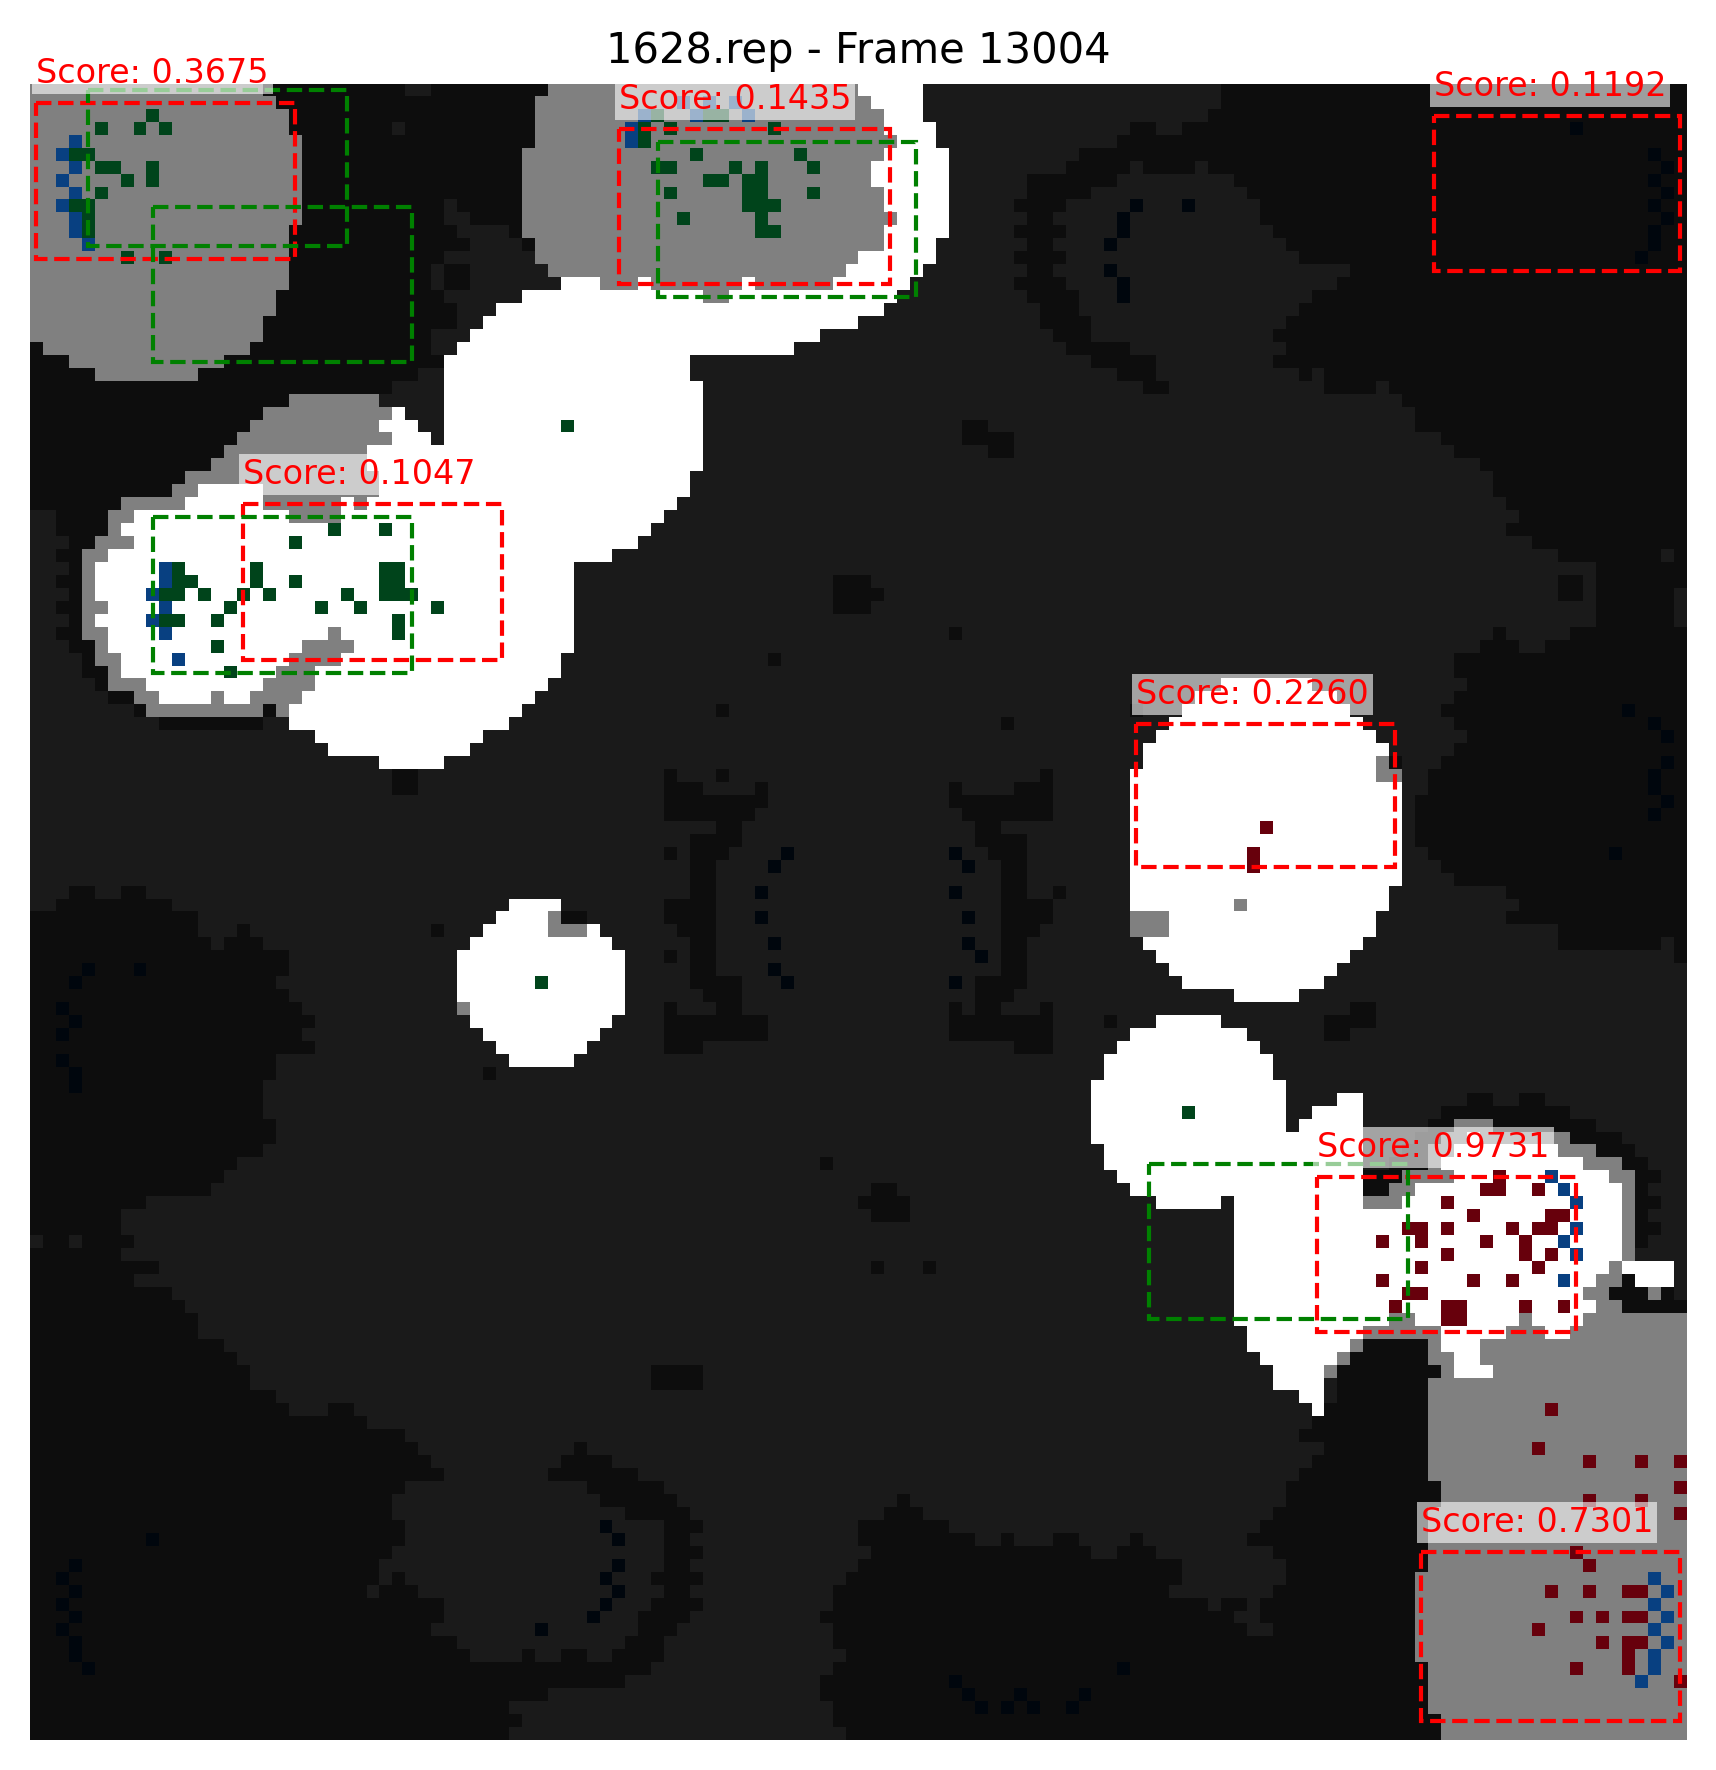

In [175]:
# draw_overview(input_numpy,
#               rep_name,
#               frame_npy, 
#               ground_truths=ground_truths['segmentation'],
#               segmentations_list=[prediction_vanilla_results['segmentation'].tolist(), prediction_kbrs_results['segmentation']])
draw_overview(input_numpy,
              rep_name,
              frame_npy, 
              ground_truths=ground_truths['segmentation'],
              dataframe_list=[prediction_vanilla_results])